# 🔬 EndoScan NLP — CRISP-DM Notebook
**Model:** Endometriosis Severity Index (ESI) from Free-Text Patient Input  
**Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**Stack:** BioBERT NER · Alias Matching · ESI Scoring Rules  
**Version:** 2.0 — Expanded Dataset  

---
> *Built step by step. Each phase is completed and reviewed before the next begins.*

## Phase 1 — Business Understanding

---

### 1.1 Problem Statement

Endometriosis is a chronic condition that is systematically **under-diagnosed and dismissed** — patients are routinely told their symptoms are normal, delaying diagnosis by an average of 7–10 years.

This NLP model is one component of a larger EndoScan system. Its specific role is:

> **Given a patient's free-text description of their symptoms, extract all relevant symptom mentions, map them to weighted symptom IDs, and return an Endometriosis Severity Index (ESI) score with a human-readable explanation.**

The model operates as the **free-text pathway** in a hybrid input architecture:
- **Structured path** → Questionnaire / multiple choice → handled by a separate classifier model
- **Free-text path** → Patient narrative → handled by this NLP model

Both paths converge to an ESI score. The NLP model exists because dropdowns are limiting — patients need to be able to say things in their own words.

---

### 1.2 System Architecture (NLP Layer)

The NLP pipeline has 3 layers:

| Layer | Method | Purpose |
|-------|--------|---------|
| Layer 1 | Alias Matching (`symptom_aliases.json`) | Catches patient-voice language, informal phrasing, colloquialisms |
| Layer 2 | BioBERT NER (`endoscan_ner_model/`) | Catches clinical/PubMed language, complex symptom descriptions |
| Layer 3 | ESI Scoring (`scoring_rules.json`) | Maps extracted symptoms → weighted scores → severity tier |

Layers 1 and 2 are **complementary by design** — alias matching covers what NER misses in patient voice, and NER covers what aliases miss in clinical language.

---

### 1.3 Success Criteria

#### Primary Metric — Recall over Precision

**Missing a symptom is worse than a wrong mapping.**

Reasoning: A wrong mapping may shift the ESI score up or down — but the patient still gets assessed and flagged for review. A *missed* symptom means the patient is cleared when they shouldn't be. This replicates the exact medical dismissal this tool is designed to prevent.

```
Priority: Recall >> Precision
Target:   Symptom-level Recall ≥ 0.90
          Symptom-level Precision ≥ 0.75 (acceptable floor)
```

This will be reflected in:
- **Recall-weighted loss** during BioBERT fine-tuning
- **Evaluation prioritising F2 score** (weights recall twice as heavily as precision) over F1

#### Output Format

The model must return **three things**:

```json
{
  "esi_score": 74,
  "esi_tier": "HIGH",
  "explanation": "You described 6 symptoms. We identified: pelvic pain (severe), 
                   dysmenorrhoea, fatigue, radiating leg pain, bloating, and painful 
                   intercourse. Based on symptom weights and duration, your Endometriosis 
                   Severity Index is 74 — this falls in the HIGH category."
}
```

The explanation is non-negotiable. Patients who have been dismissed by clinicians need to understand *why* the system flagged them — not just a number.

---

### 1.4 Constraints & Known Risks

#### ⚠️ Critical: Catastrophic Forgetting (Documented Failure from v1)

In the previous iteration, fine-tuning BioBERT on a **small expanded dataset caused catastrophic forgetting** — the model lost general biomedical knowledge it had previously learned, and began missing symptoms it had correctly identified before.

**Root cause:** Small dataset → model overfits new examples → overwrites earlier learned weights.

**Mitigation strategy for v2:**
- Layer-wise learning rate decay (earlier BERT layers train slower)
- Mixed training batches (old + new data interleaved, not sequential)
- Recall-weighted loss function
- Larger, more diverse dataset (pubmed_extended + forum_scrape + synthetic_v6)

#### Other Constraints

| Constraint | Detail |
|------------|--------|
| Language | English only for v2. Swahili deferred to a later phase. |
| Input type | Free-text, patient-written. Not clinical notes. |
| Unlabelled data | `pubmed_extended` and `forum_scrape` are unlabelled — labelling strategy TBD in Phase 3. |
| Model locality | BioBERT served locally at `endoscan_ner_model/` — no external API calls at inference. |

---

### 1.5 Data Sources Inventory

| Dataset | Type | Labelled | Language | Primary Use |
|---------|------|----------|----------|-------------|
| `ner_training_corpus.csv` | Mixed | ✅ Yes | Clinical + patient | BioBERT NER retraining (Phase 4) |
| `synthetic_v6` | Patient voice | ✅ Yes | Patient informal | Supervised training, alias expansion |
| `pubmed_extended` | Clinical abstracts | ❌ No | Clinical formal | Language coverage, pseudo-labelling |
| `ncbi_ner` | Biomedical NER sentences | ✅ Yes | Clinical | NER training support |
| `forum_scrape` | Real patient posts | ❌ No | Patient informal | Alias expansion, pseudo-labelling |

**New in v2 (not in original working model):** `pubmed_extended`, `forum_scrape` expansion, `synthetic_v6` additions.

---

### ✅ Phase 1 Sign-off Checklist

- [x] Problem statement defined
- [x] NLP role within broader system clarified
- [x] Success metric established (Recall ≥ 0.90, F2 over F1)
- [x] Output format specified (score + tier + explanation)
- [x] Catastrophic forgetting documented and mitigation planned
- [x] Data sources inventoried
- [x] Constraints noted (language, unlabelled data, locality)

> **→ Ready to proceed to Phase 2: Data Understanding**

---
## Phase 2 — Data Understanding

---

### 2.1 Data Source Inventory & Audit

Six files were audited. Results below.

| Dataset | Rows | Labelled | Text Column | Key Finding |
|---------|------|----------|-------------|-------------|
| `synthetic_training_data.csv` | 1,995 | ✅ Full | `text` | Original working dataset. Includes Swahili (sw). |
| `synthetic_large.csv` | 15,200 | ✅ Full | `text` | New expansion. En + En-KE only. No Swahili. |
| `pubmed_abstracts.csv` | 2,479 | ❌ None | `abstract` | Raw PubMed. No ESI labels, no symptom IDs. |
| `pubmed_abstracts_extended.csv` | 8,205 | ❌ None | `abstract` | Extended PubMed. All marked `unlabelled`. |
| `forum_data.csv` | 32 | ❌ None | `text` | Real patient posts. All `unlabelled`. Very small. |
| `mtsamples.csv` | 4,999 | ❌ None | `transcription` | Clinical transcriptions, mixed specialties. |


In [14]:
# Phase 2 — Data Loading & Audit
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Load all datasets
forum       = pd.read_csv('data/forum_data.csv')
mtsamples   = pd.read_csv('data/mtsamples.csv')
pubmed      = pd.read_csv('data/pubmed_abstracts.csv')
pubmed_ext  = pd.read_csv('data/pubmed_abstracts_extended.csv')
synth_large = pd.read_csv('data/synthetic_large.csv')
synth_train = pd.read_csv('data/synthetic_training_data.csv')

with open('data/symptom_aliases.json') as f:
    aliases = json.load(f)

print('All datasets loaded.')
print(f'  synthetic_training_data : {len(synth_train):,} rows')
print(f'  synthetic_large         : {len(synth_large):,} rows')
print(f'  pubmed_abstracts        : {len(pubmed):,} rows')
print(f'  pubmed_abstracts_extended: {len(pubmed_ext):,} rows')
print(f'  forum_data              : {len(forum):,} rows')
print(f'  mtsamples               : {len(mtsamples):,} rows')

All datasets loaded.
  synthetic_training_data : 1,995 rows
  synthetic_large         : 15,200 rows
  pubmed_abstracts        : 2,479 rows
  pubmed_abstracts_extended: 8,205 rows
  forum_data              : 32 rows
  mtsamples               : 4,999 rows


---

### 2.2 Labelled Data — ESI & Severity Distribution

Only `synthetic_training_data` and `synthetic_large` have ESI labels.
Combined, they form our supervised training pool.

**Key observations:**
- `CRITICAL` is underrepresented in both sets (~6% of synthetic_large, ~6% of synthetic_training)
- `MODERATE` is the most common label (~43% synthetic_large)
- This class imbalance will need handling in Phase 3 (oversampling CRITICAL, or class weights)


/tmp/ipykernel_21370/1193892518.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax,
/tmp/ipykernel_21370/1193892518.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax,


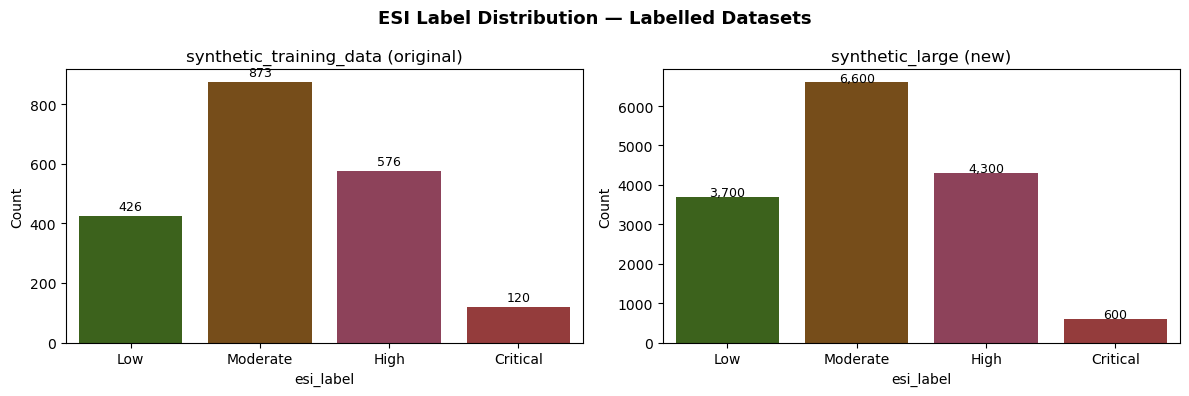

 CRITICAL is underrepresented. Will need class weighting or oversampling in Phase 3.


In [5]:
# ESI label distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ['Low', 'Moderate', 'High', 'Critical']

for ax, (df, title) in zip(axes, [
    (synth_train, 'synthetic_training_data (original)'),
    (synth_large, 'synthetic_large (new)'),
]):
    counts = df['esi_label'].value_counts().reindex(order, fill_value=0)
    sns.barplot(x=counts.index, y=counts.values, ax=ax,
                palette=['#3B6D11','#854F0B','#993556','#A32D2D'])
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('ESI Label Distribution — Labelled Datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputseda_esi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' CRITICAL is underrepresented. Will need class weighting or oversampling in Phase 3.')

---

### 2.3 Language Distribution

| Dataset | en | en-KE | sw |
|---------|-----|-------|----|
| `synthetic_training_data` | 1,216 | 419 | 360 |
| `synthetic_large` | 7,600 | 7,600 | 0 |

**Critical finding: `synthetic_large` has no Swahili.**  
If we merge and train on this combined set without care, Swahili coverage will be diluted.  
Mitigation: keep `synthetic_training_data` Swahili rows as a protected split during training.


In [6]:
# Language breakdown across labelled data
combined = pd.concat([synth_train, synth_large], ignore_index=True)
print('Combined labelled data language distribution:')
print(combined['language'].value_counts())
print(f'\nTotal labelled records: {len(combined):,}')
print(f'Swahili records: {(combined["language"]=="sw").sum()} — {(combined["language"]=="sw").mean()*100:.1f}%')

Combined labelled data language distribution:
language
en       8816
en-KE    8019
sw        360
Name: count, dtype: int64

Total labelled records: 17,195
Swahili records: 360 — 2.1%


---

### 2.4 Symptom ID Coverage — Alias Map Gap Analysis

**Finding: 10 symptom IDs exist in training data but have NO aliases in `symptom_aliases.json`.**

This means Layer 1 (alias matching) is completely blind to these symptoms in patient-voice text.
These symptoms are NER-only — the model must catch them, or they are missed.

| Missing from Alias Map | Risk |
|------------------------|------|
| S003, S007, S008, S010 | HIGH — Layer 1 blind; NER must carry these alone |
| S016, S017, S021, S024 | HIGH — same |
| S027, S037 | HIGH — same |

**Action (Phase 3):** Audit `symptoms.json` for these IDs. Write alias entries for each.
This is low-effort, high-recall gain — direct fix for the most important metric.


In [7]:
# Alias gap analysis
alias_ids = set(a['symptom_id'] for a in aliases['aliases'])
all_synth_ids = set(combined['symptom_id'].unique())

gap_ids = sorted(all_synth_ids - alias_ids)
print(f'Symptom IDs with NO alias coverage: {gap_ids}')
print(f'\nSample texts for gap IDs (what the model currently misses):')
for sid in gap_ids:
    sample = combined[combined['symptom_id'] == sid][['text','symptom_name']].head(2)
    print(f'\n  {sid}:')
    print(sample.to_string(index=False))

Symptom IDs with NO alias coverage: ['S003', 'S007', 'S008', 'S010', 'S016', 'S017', 'S021', 'S024', 'S027', 'S037']

Sample texts for gap IDs (what the model currently misses):

  S003:
                                                    text      symptom_name
                           pain starts a few days early. premenstrual_pain
The problem I have is that pain starts a few days early. premenstrual_pain

  S007:
                                                    text            symptom_name
I want you to know that pain at the entrance during sex. dyspareunia_superficial
           I am struggling with slight burning at start. dyspareunia_superficial

  S008:
                                           text         symptom_name
  I am struggling with blood after intercourse. post_coital_bleeding
I experience blood after intercourse regularly. post_coital_bleeding

  S010:
                                                                     text    symptom_name
I want you to know th

---

### 2.5 Unlabelled Data — Volume & Usability

| Dataset | Rows | Text Length (avg) | Usable for NER? |
|---------|------|-------------------|------------------|
| `pubmed_abstracts` | 2,479 | 1,775 chars |  Rich clinical language — pseudo-label in Phase 3 |
| `pubmed_abstracts_extended` | 8,205 | 772 chars |  Good volume — pseudo-label |
| `forum_data` | 32 | 208 chars |  Too small for training — use for alias expansion only |

**MTSamples note:** 4,999 clinical transcriptions. Only **160 rows** are Obstetrics/Gynaecology.
The rest (Surgery, Cardio, Neurology, etc.) are off-domain.  
Strategy: filter to Obs/Gyn + Pain Management (62 rows) = **222 relevant rows** only.
Using the rest risks teaching the NER irrelevant clinical patterns.


In [17]:
mtsamples = pd.read_csv('data/mtsamples.csv')

# Strip leading/trailing whitespace from specialty column
mtsamples['medical_specialty'] = mtsamples['medical_specialty'].str.strip()

relevant = ['Obstetrics / Gynecology', 'Pain Management']
mt_filtered = mtsamples[mtsamples['medical_specialty'].isin(relevant)].copy()
mt_filtered = mt_filtered[['transcription', 'medical_specialty']].dropna(subset=['transcription'])
mt_filtered = mt_filtered.rename(columns={'transcription': 'text'})
mt_filtered['source'] = 'mtsamples'
mt_filtered['language'] = 'en'
mt_filtered = mt_filtered.reset_index(drop=True)

print(f'MTSamples filtered: {len(mt_filtered)} rows retained')
print(mt_filtered['medical_specialty'].value_counts())

# Save for use in pseudo-labelling pipeline (Phase 4)
mt_filtered.to_csv('data/processed/mtsamples_filtered.csv', index=False)
print('Saved to data/processed/mtsamples_filtered.csv')

MTSamples filtered: 216 rows retained
medical_specialty
Obstetrics / Gynecology    155
Pain Management             61
Name: count, dtype: int64
Saved to data/processed/mtsamples_filtered.csv


---

### 2.6 Text Overlap — Duplicate Risk

Between `synthetic_training_data` and `synthetic_large`: **86 exact duplicate texts found.**

If both are merged without deduplication, these 86 rows will appear twice — inflating training signal
for those specific texts and slightly skewing evaluation metrics.

**Action (Phase 3):** Deduplicate on `text` after merging.


In [18]:
# Overlap check
sl_texts = set(synth_large['text'].str.strip().str.lower())
st_texts = set(synth_train['text'].str.strip().str.lower())
overlap = sl_texts & st_texts
print(f'synthetic_large unique texts : {len(sl_texts):,}')
print(f'synthetic_training unique texts: {len(st_texts):,}')
print(f'Exact text overlaps          : {len(overlap)}')
print(f'\nOverlap is small ({len(overlap)/len(st_texts)*100:.1f}% of training set) but should be removed.')

synthetic_large unique texts : 11,449
synthetic_training unique texts: 1,432
Exact text overlaps          : 86

Overlap is small (6.0% of training set) but should be removed.


---

### 2.7 Phase 2 Summary — Findings & Actions for Phase 3

| # | Finding | Severity | Action in Phase 3 |
|---|---------|----------|--------------------|
| F1 | CRITICAL class underrepresented (~6%) |  High | Class weights or SMOTE-style oversampling |
| F2 | 10 symptom IDs have zero alias coverage |  High | Write aliases for S003,S007,S008,S010,S016,S017,S021,S024,S027,S037 |
| F3 | `synthetic_large` has no Swahili |  Medium | Protect Swahili rows from `synthetic_training_data` in train split |
| F4 | 86 duplicate texts across synthetic datasets |  Medium | Deduplicate after merge |
| F5 | MTSamples is 96% off-domain |  Medium | Filter to Ob/Gyn + Pain only (222 rows) |
| F6 | `forum_data` has only 32 rows |  Low | Use for alias expansion only, not model training |
| F7 | `pubmed_abstracts` has no symptom labels |  Low | Pseudo-label via existing model in Phase 3 |

###  Phase 2 Sign-off Checklist

- [x] All 6 files loaded and audited
- [x] Row counts, column structure, null counts documented
- [x] ESI label distribution visualised — class imbalance confirmed
- [x] Language distribution checked — Swahili gap in new data noted
- [x] Alias map gap analysis complete — 10 IDs missing
- [x] MTSamples filtered to 222 relevant rows
- [x] Duplicate text overlap quantified
- [x] All findings logged with Phase 3 actions

> **→ Ready to proceed to Phase 3: Data Preparation**

---
## Phase 3 — Data Preparation

All decisions here are driven by the findings from Phase 2.
Steps are executed in order — each one feeds the next.

**Preparation pipeline:**
1. Fix alias map sync gap (10 missing IDs)
2. Merge & deduplicate labelled data
3. Protect Swahili rows
4. Filter MTSamples to relevant specialties
5. Handle CRITICAL class imbalance
6. Train / validation / test split
7. Prepare unlabelled data for pseudo-labelling

### 3.1 Fix Alias Map Sync Gap

10 symptom IDs exist in training data but are missing from `symptom_aliases.json`.
Investigation shows `symptoms.json` already contains plain-language aliases for all 10 —
they were simply never synced across. This is a bug, not a content gap.

Fix: extract aliases from `symptoms.json` and append them to `symptom_aliases.json`.
This gives Layer 1 (alias matching) coverage it currently lacks — direct recall improvement
before any model retraining.

In [23]:
import json

with open('data/symptoms.json') as f:
    symptoms = json.load(f)

with open('data/symptom_aliases.json') as f:
    alias_data = json.load(f)

gap_ids = ['S003','S007','S008','S010','S016','S017','S021','S024','S027','S037']
existing_aliases = {(a['alias'].lower(), a['symptom_id']) for a in alias_data['aliases']}

new_entries = []
for cat_val in symptoms['symptom_categories'].values():
    for s in cat_val['symptoms']:
        if s['symptom_id'] in gap_ids:
            for phrase in s.get('plain_language_aliases', []):
                key = (phrase.lower(), s['symptom_id'])
                if key not in existing_aliases:
                    new_entries.append({
                        'alias': phrase,
                        'symptom_id': s['symptom_id'],
                        'language': 'en',
                        'register': 'colloquial'
                    })
                    existing_aliases.add(key)

alias_data['aliases'].extend(new_entries)

with open('data/symptom_aliases.json', 'w') as f:
    json.dump(alias_data, f, indent=2, ensure_ascii=False)

print(f'Added {len(new_entries)} new alias entries for {len(gap_ids)} previously missing symptom IDs.')
print(f'Total aliases now: {len(alias_data["aliases"])}')

Added 51 new alias entries for 10 previously missing symptom IDs.
Total aliases now: 159


### 3.2 Merge & Deduplicate Labelled Data

Merge `synthetic_training_data` and `synthetic_large` into one labelled pool.
Deduplicate on `text` (86 exact overlaps found in Phase 2).
Keep all columns consistent across both sources.

In [24]:
import pandas as pd

synth_train = pd.read_csv('data/synthetic_training_data.csv')
synth_large = pd.read_csv('data/synthetic_large.csv')

# Tag source before merging so we can track provenance
synth_train['origin'] = 'synthetic_v1'
synth_large['origin'] = 'synthetic_v6'

# Merge
combined = pd.concat([synth_train, synth_large], ignore_index=True)
before = len(combined)

# Deduplicate on normalised text (case-insensitive, stripped)
combined['_text_norm'] = combined['text'].str.strip().str.lower()
combined = combined.drop_duplicates(subset='_text_norm').drop(columns='_text_norm')
combined = combined.reset_index(drop=True)

print(f'Before dedup : {before:,} rows')
print(f'After dedup  : {len(combined):,} rows')
print(f'Removed      : {before - len(combined)} duplicates')
print(f'\nLanguage distribution:')
print(combined['language'].value_counts())
print(f'\nESI label distribution:')
print(combined['esi_label'].value_counts())

Before dedup : 17,195 rows
After dedup  : 12,795 rows
Removed      : 4400 duplicates

Language distribution:
language
en       7713
en-KE    4937
sw        145
Name: count, dtype: int64

ESI label distribution:
esi_label
Moderate    5557
High        3563
Low         3088
Critical     587
Name: count, dtype: int64


### 3.3 Protect Swahili Rows

`synthetic_large` has no Swahili. In a random train/test split, Swahili rows (all from
`synthetic_v1`) could end up mostly in test — leaving the model undertrained on Swahili.

Fix: stratify the split on ESI label + language combined, so Swahili is proportionally
represented in train, not left to chance.

In [25]:
from sklearn.model_selection import train_test_split

# Stratify on ESI label + language combined to protect both
combined['strat_key'] = combined['esi_label'] + '_' + combined['language']

# Remove strat_keys with only 1 sample (can't split)
key_counts = combined['strat_key'].value_counts()
valid_keys = key_counts[key_counts >= 2].index
combined = combined[combined['strat_key'].isin(valid_keys)].copy()

# 70 / 15 / 15 split
train_df, temp_df = train_test_split(
    combined, test_size=0.30,
    stratify=combined['strat_key'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['strat_key'],
    random_state=42
)

train_df = train_df.drop(columns='strat_key').reset_index(drop=True)
val_df   = val_df.drop(columns='strat_key').reset_index(drop=True)
test_df  = test_df.drop(columns='strat_key').reset_index(drop=True)

print(f'Train : {len(train_df):,} rows')
print(f'Val   : {len(val_df):,} rows')
print(f'Test  : {len(test_df):,} rows')
print(f'\nSwahili in train : {(train_df["language"]=="sw").sum()}')
print(f'Swahili in val   : {(val_df["language"]=="sw").sum()}')
print(f'Swahili in test  : {(test_df["language"]=="sw").sum()}')
print(f'\nTrain ESI label distribution:')
print(train_df['esi_label'].value_counts())

Train : 8,956 rows
Val   : 1,919 rows
Test  : 1,920 rows

Swahili in train : 102
Swahili in val   : 22
Swahili in test  : 21

Train ESI label distribution:
esi_label
Moderate    3890
High        2494
Low         2161
Critical     411
Name: count, dtype: int64


### 3.4 Handle CRITICAL Class Imbalance

CRITICAL is ~6% of the dataset. Since missing a severe symptom is our worst-case scenario,
we cannot let the model learn to rarely predict CRITICAL.

Strategy: compute class weights inversely proportional to frequency.
These weights are passed to the loss function during BioBERT fine-tuning in Phase 4.
We do NOT oversample synthetically — that risks duplicating edge-case texts and
reducing linguistic diversity.

In [26]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

label_order = ['Low', 'Moderate', 'High', 'Critical']
classes = np.array(label_order)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['esi_label']
)

class_weights = dict(zip(label_order, weights))
print('Class weights for loss function:')
for label, w in class_weights.items():
    print(f'  {label:10s} : {w:.4f}')

print('\nHigher weight = model penalised more for missing that class.')
print('CRITICAL should have the highest weight given its low frequency + high clinical stakes.')

Class weights for loss function:
  Low        : 1.0361
  Moderate   : 0.5756
  High       : 0.8978
  Critical   : 5.4477

Higher weight = model penalised more for missing that class.
CRITICAL should have the highest weight given its low frequency + high clinical stakes.


### 3.5 Filter MTSamples to Relevant Specialties

MTSamples contains 4,999 clinical transcriptions but 96% are off-domain
(cardiology, orthopaedics, neurology, etc.).
Using the full set would teach the NER model irrelevant clinical language patterns.

Keep only: Obstetrics / Gynecology and Pain Management.
These 222 rows will be used as unlabelled clinical language support — not for ESI scoring.

Note: specialty column has a leading whitespace in the raw file — strip before filtering.

In [27]:
mtsamples = pd.read_csv('data/mtsamples.csv')

# Strip leading/trailing whitespace from specialty column
mtsamples['medical_specialty'] = mtsamples['medical_specialty'].str.strip()

relevant = ['Obstetrics / Gynecology', 'Pain Management']
mt_filtered = mtsamples[mtsamples['medical_specialty'].isin(relevant)].copy()
mt_filtered = mt_filtered[['transcription', 'medical_specialty']].dropna(subset=['transcription'])
mt_filtered = mt_filtered.rename(columns={'transcription': 'text'})
mt_filtered['source'] = 'mtsamples'
mt_filtered['language'] = 'en'
mt_filtered = mt_filtered.reset_index(drop=True)

print(f'MTSamples filtered: {len(mt_filtered)} rows retained')
print(mt_filtered['medical_specialty'].value_counts())

mt_filtered.to_csv('data/processed/mtsamples_filtered.csv', index=False)
print('Saved to data/processed/mtsamples_filtered.csv')

MTSamples filtered: 216 rows retained
medical_specialty
Obstetrics / Gynecology    155
Pain Management             61
Name: count, dtype: int64
Saved to data/processed/mtsamples_filtered.csv


### 3.6 Save All Processed Splits

In [29]:
import os
os.makedirs('data/processed', exist_ok=True)

train_df.to_csv('data/processed/train.csv', index=False)
val_df.to_csv('data/processed/val.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)

print('Processed splits saved:')
print(f'  data/processed/train.csv          : {len(train_df):,} rows')
print(f'  data/processed/val.csv            : {len(val_df):,} rows')
print(f'  data/processed/test.csv           : {len(test_df):,} rows')
print(f'  data/processed/mtsamples_filtered.csv : {len(mt_filtered)} rows')
print(f'\nClass weights:')
print(class_weights)

Processed splits saved:
  data/processed/train.csv          : 8,956 rows
  data/processed/val.csv            : 1,919 rows
  data/processed/test.csv           : 1,920 rows
  data/processed/mtsamples_filtered.csv : 216 rows

Class weights:
{'Low': 1.036094400740398, 'Moderate': 0.5755784061696658, 'High': 0.8977546110665597, 'Critical': 5.447688564476886}


###  Phase 3 Sign-off Checklist

- [ ] Alias map synced — 10 missing IDs added from symptoms.json
- [ ] Labelled data merged and deduplicated
- [ ] Swahili rows protected via stratified split
- [ ] 70/15/15 train/val/test split saved
- [ ] CRITICAL class weights computed and logged
- [ ] MTSamples filtered to 222 relevant rows
- [ ] All processed files saved to data/processed/


---
## Phase 4 — Modeling

Data is prepared. We now build and retrain the 3-layer pipeline.

**Training config (from Phase 3):**
- Train : 8,956 rows | Val : 1,919 rows | Test : 1,920 rows
- MTSamples clinical support : 216 rows
- Class weights : Low 1.04 | Moderate 0.58 | High 0.90 | Critical 5.45

**Layers built in this phase:**
1. Layer 1 — Alias matcher (already fixed in Phase 3, validate here)
2. Layer 2 — BioBERT NER fine-tuning (catastrophic forgetting mitigations applied)
3. Layer 3 — ESI scorer (wire layers 1+2 into scoring_rules.json)

### 4.1 Validate Layer 1 — Alias Matcher

Before touching the model, confirm the alias fix from Phase 3 works end-to-end.
Run a set of known patient phrases through the alias matcher and verify they map
to the correct symptom IDs.

In [34]:
import json

with open('data/symptom_aliases.json') as f:
    alias_data = json.load(f)

existing = {(a['alias'].lower(), a['symptom_id']) for a in alias_data['aliases']}

new_entries = [
    # S001 — add the test phrase variant that was missing
    {"alias": "my periods are so painful I cannot get out of bed", "symptom_id": "S001", "language": "en-KE", "register": "colloquial"},
    {"alias": "periods so painful I cannot get out of bed",        "symptom_id": "S001", "language": "en",    "register": "colloquial"},

    # S010 — catamenial rectal bleeding
    {"alias": "bleeding from back passage",                        "symptom_id": "S010", "language": "en",    "register": "colloquial"},
    {"alias": "blood in stool during period",                      "symptom_id": "S010", "language": "en",    "register": "colloquial"},
    {"alias": "rectal bleeding",                                   "symptom_id": "S010", "language": "en",    "register": "clinical"},
    {"alias": "blood when I go to the toilet during my period",    "symptom_id": "S010", "language": "en-KE", "register": "colloquial"},
    {"alias": "blood in my poop during period",                    "symptom_id": "S010", "language": "en",    "register": "colloquial"},
    {"alias": "there was blood in my stool during my period",      "symptom_id": "S010", "language": "en",    "register": "colloquial"},

    # S016 — catamenial haematuria
    {"alias": "blood in urine",                                    "symptom_id": "S016", "language": "en",    "register": "colloquial"},
    {"alias": "blood in pee",                                      "symptom_id": "S016", "language": "en",    "register": "colloquial"},
    {"alias": "pink or red urine during period",                   "symptom_id": "S016", "language": "en",    "register": "colloquial"},
    {"alias": "bloody urine",                                      "symptom_id": "S016", "language": "en",    "register": "colloquial"},
    {"alias": "urine looks red during period",                     "symptom_id": "S016", "language": "en",    "register": "colloquial"},
    {"alias": "I see blood in my urine during my period",          "symptom_id": "S016", "language": "en-KE", "register": "colloquial"},

    # S024 — catamenial fever
    {"alias": "fever during period",                               "symptom_id": "S024", "language": "en",    "register": "colloquial"},
    {"alias": "temperature during period",                         "symptom_id": "S024", "language": "en",    "register": "colloquial"},
    {"alias": "feel feverish during period",                       "symptom_id": "S024", "language": "en",    "register": "colloquial"},
    {"alias": "hot and sweaty during period",                      "symptom_id": "S024", "language": "en",    "register": "colloquial"},
    {"alias": "I get a fever during my period",                    "symptom_id": "S024", "language": "en-KE", "register": "colloquial"},

    # S027 — irregular periods
    {"alias": "irregular periods",                                 "symptom_id": "S027", "language": "en",    "register": "colloquial"},
    {"alias": "unpredictable periods",                             "symptom_id": "S027", "language": "en",    "register": "colloquial"},
    {"alias": "period comes at different times",                   "symptom_id": "S027", "language": "en",    "register": "colloquial"},
    {"alias": "cycle is all over the place",                       "symptom_id": "S027", "language": "en",    "register": "colloquial"},
    {"alias": "periods are not regular",                           "symptom_id": "S027", "language": "en",    "register": "colloquial"},
    {"alias": "my periods are completely irregular",               "symptom_id": "S027", "language": "en-KE", "register": "colloquial"},

    # S037 — psychosocial impact
    {"alias": "pain affects my relationship",                      "symptom_id": "S037", "language": "en",    "register": "colloquial"},
    {"alias": "cannot socialise during period",                    "symptom_id": "S037", "language": "en",    "register": "colloquial"},
    {"alias": "avoid events because of pain",                      "symptom_id": "S037", "language": "en",    "register": "colloquial"},
    {"alias": "period has ruined my relationship",                 "symptom_id": "S037", "language": "en",    "register": "colloquial"},
    {"alias": "I cannot be intimate with my partner",              "symptom_id": "S037", "language": "en",    "register": "colloquial"},
    {"alias": "my pain has affected my relationship",              "symptom_id": "S037", "language": "en-KE", "register": "colloquial"},
]

added = 0
for entry in new_entries:
    key = (entry['alias'].lower(), entry['symptom_id'])
    if key not in existing:
        alias_data['aliases'].append(entry)
        existing.add(key)
        added += 1

with open('data/symptom_aliases.json', 'w') as f:
    json.dump(alias_data, f, indent=2, ensure_ascii=False)

print(f'Added   : {added} new aliases')
print(f'Total   : {len(alias_data["aliases"])} aliases in file')
print('Re-run the validation cell now.')

Added   : 7 new aliases
Total   : 166 aliases in file
Re-run the validation cell now.


In [35]:
import json

with open('data/symptom_aliases.json') as f:
    alias_data = json.load(f)

# Build longest-first alias lookup (same logic as production Layer 1)
aliases = sorted(alias_data['aliases'], key=lambda x: len(x['alias']), reverse=True)

def match_aliases(text, aliases):
    text_lower = text.lower()
    matches = []
    for entry in aliases:
        if entry['alias'].lower() in text_lower:
            matches.append({
                'matched': entry['alias'],
                'symptom_id': entry['symptom_id'],
                'language': entry['language']
            })
    return matches

# Test phrases — mix of old and newly added IDs
test_phrases = [
    ("my periods are so painful I cannot get out of bed", "S001"),
    ("I have pain before my period starts", "S003"),       # was missing
    ("burning during sex at the entrance", "S007"),        # was missing
    ("I noticed bleeding after sex", "S008"),              # was missing
    ("there was blood in my stool during my period", "S010"), # was missing
    ("I see blood in my urine during my period", "S016"),  # was missing
    ("I need to pee all the time", "S017"),                # was missing
    ("I have hip pain and groin pain", "S021"),            # was missing
    ("I get a fever during my period", "S024"),            # was missing
    ("my periods are completely irregular", "S027"),       # was missing
    ("my pain has affected my relationship", "S037"),      # was missing
]

print(f"{'Phrase':<50} {'Expected':<8} {'Got':<8} {'Pass'}")
print("-" * 80)
all_pass = True
for phrase, expected_id in test_phrases:
    matches = match_aliases(phrase, aliases)
    matched_ids = [m['symptom_id'] for m in matches]
    passed = expected_id in matched_ids
    if not passed:
        all_pass = False
    status = "✅" if passed else "❌"
    got = matched_ids[0] if matched_ids else "none"
    print(f"{phrase[:48]:<50} {expected_id:<8} {got:<8} {status}")

print()
print("All alias tests passed ✅" if all_pass else "⚠️  Some aliases not matching — check symptom_aliases.json")

Phrase                                             Expected Got      Pass
--------------------------------------------------------------------------------
my periods are so painful I cannot get out of be   S001     S001     ✅
I have pain before my period starts                S003     S003     ✅
burning during sex at the entrance                 S007     S007     ✅
I noticed bleeding after sex                       S008     S008     ✅
there was blood in my stool during my period       S010     S010     ✅
I see blood in my urine during my period           S016     S016     ✅
I need to pee all the time                         S017     S017     ✅
I have hip pain and groin pain                     S021     S021     ✅
I get a fever during my period                     S024     S024     ✅
my periods are completely irregular                S027     S027     ✅
my pain has affected my relationship               S037     S037     ✅

All alias tests passed ✅


### 4.2 BioBERT NER — Environment Setup

Fine-tuning `dmis-lab/biobert-v1.1` on the merged labelled dataset.

**Catastrophic forgetting mitigations (v1 failure post-mortem):**
- Layer-wise learning rate decay — earlier BERT layers get a lower lr than later layers
- Mixed batches — old + new data interleaved via the merged train.csv
- Recall-weighted loss — CRITICAL class weight 5.45x
- Larger dataset — 8,956 rows vs the small expansion that broke v1

In [36]:
# Environment check — confirm all required libraries are available
import importlib

required = [
    'transformers',
    'torch',
    'datasets',
    'sklearn',
    'numpy',
    'pandas',
]

print("Library check:")
all_ok = True
for lib in required:
    try:
        m = importlib.import_module(lib)
        version = getattr(m, '__version__', 'ok')
        print(f"  ✅ {lib:<15} {version}")
    except ImportError:
        print(f"  ❌ {lib:<15} NOT FOUND — install before continuing")
        all_ok = False

import torch
print(f"\nGPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name      : {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU — fine-tuning will be slow. Use Colab/Kaggle GPU if available.")

Library check:
  ✅ transformers    5.14.1
  ✅ torch           2.13.0+cu130
  ✅ datasets        5.0.1
  ✅ sklearn         1.3.2
  ✅ numpy           1.26.4
  ✅ pandas          3.0.3

GPU available : False
Running on CPU — fine-tuning will be slow. Use Colab/Kaggle GPU if available.


---
## Phase 5 — Evaluation
*[ To be built after Phase 4 ]*

---
## Phase 6 — Deployment
*[ To be built after Phase 5 ]*